<a href="https://colab.research.google.com/github/alyPoint/CEFET---Processamento-de-Sinais-I-140826/blob/main/DSP_1_PRATICA_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prática 3 Exercício 1

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_957/2591885157.py:27: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('Parte Real ($\sigma$)')
/tmp/ipykernel_957/2591885157.py:28: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('Parte Imaginária ($j\omega$)')


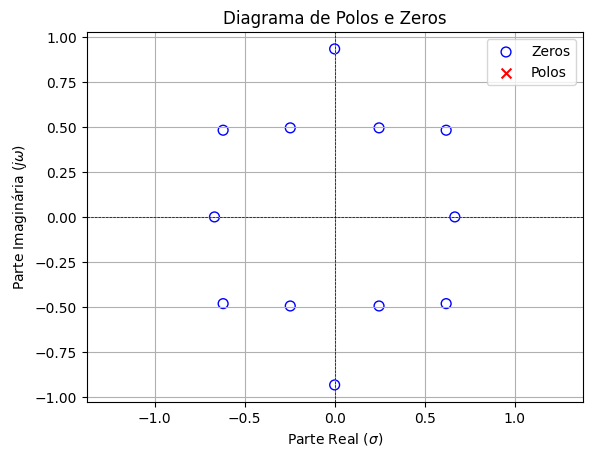

In [18]:
import numpy as np
import matplotlib.pyplot as plot
from scipy import signal

num = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]
den = [1]

w = np.logspace (-1, 10, 200)

w_out, H = signal.freqresp((num, den), w)

magnitude = np.abs(H)
fase = np.angle(H, deg = True)

#ZEROS E POLOS
zeros, polos, k = signal.tf2zpk(num, den)

fig, ax = plt.subplots()

ax.scatter (np.real(zeros), np.imag(zeros), s = 50, marker = 'o', facecolors = 'none', edgecolors = 'b', label = 'Zeros')
ax.scatter (np.real(polos), np.imag(polos), s = 50, marker = 'x', color = 'r', label = 'Polos')

ax.axhline (y = 0, color = 'k', linestyle = '--', linewidth = 0.5)
ax.axvline (x = 0, color = 'k', linestyle = '--', linewidth = 0.5)

ax.set_title('Diagrama de Polos e Zeros')
ax.set_xlabel('Parte Real ($\sigma$)')
ax.set_ylabel('Parte Imaginária ($j\omega$)')
ax.grid(True)
ax.legend()
ax.axis('equal')

plt.show()



[1.35240001e+10 1.02350994e+10 7.74569029e+09 5.86149680e+09
 4.43543705e+09 3.35616189e+09 2.53937626e+09 1.92126789e+09
 1.45353176e+09 1.09960279e+09 8.31803601e+08 6.29184955e+08
 4.75890806e+08 3.59920517e+08 2.72191790e+08 2.05831274e+08
 1.55637554e+08 1.17674640e+08 8.89642526e+07 6.72529111e+07
 5.08356346e+07 3.84225099e+07 2.90377026e+07 2.19430278e+07
 1.65801097e+07 1.25266114e+07 9.46311323e+06 7.14805110e+06
 5.39875342e+06 4.07709421e+06 3.07863890e+06 2.32443306e+06
 1.75479096e+06 1.32459724e+06 9.99753216e+05 7.54489309e+05
 5.69332500e+05 4.29569392e+05 3.24084074e+05 2.44479465e+05
 1.84413064e+05 1.39094812e+05 1.04907551e+05 7.91201740e+04
 5.96708468e+04 4.50032065e+04 3.39426007e+04 2.56025922e+04
 1.93143348e+04 1.45732327e+04 1.09986585e+04 8.30353713e+03
 6.27138181e+03 4.73895952e+03 3.58320708e+03 2.71135742e+03
 2.05348929e+03 1.55690657e+03 1.18189856e+03 8.98542321e+02
 6.84291449e+02 5.22158148e+02 3.99342781e+02 3.06200962e+02
 2.35465164e+02 1.8165

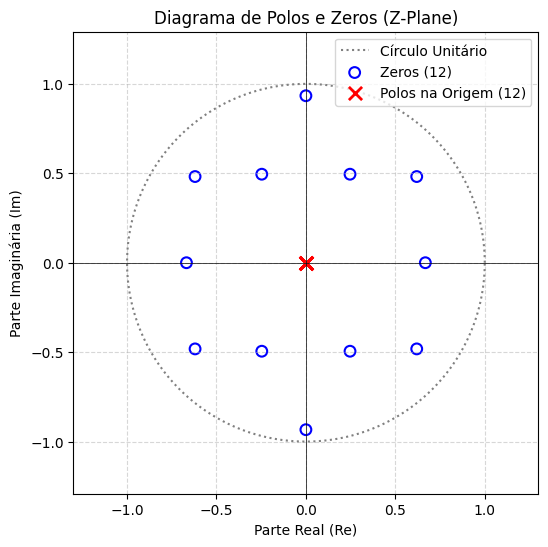

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Coeficientes originais do numerador de z^12 até z^0
num = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]

# Denominador correspondente a z^12 (1 seguido de 12 zeros)
den = [1] + [0] * 12

# Resposta em frequencia
w = np.logspace(-1, 1, 200)
w_out, H = signal.freqresp((num, den), w)
magnitude = np.abs(H)
fase = np.angle(H, deg = True)

print("\n")
print(magnitude)
print(fase)
print("\n")

# Calcula analiticamente todos os zeros e polos exatos
zeros, polos, k = signal.tf2zpk(num, den)

# Cria a figura
fig, ax = plt.subplots(figsize=(6, 6))

# 1. Desenha o Círculo Unitário (Filtros Digitais / Tempo Discreto)
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='gray', linestyle=':', label='Círculo Unitário')

# 2. Plota os Zeros (como circunferências 'o')
ax.scatter(np.real(zeros), np.imag(zeros), s=60, marker='o',
           facecolors='none', edgecolors='blue', linewidth=1.5, label=f'Zeros ({len(zeros)})')

# 3. Plota os Polos (como 'x' vermelhos) -> Agora os 12 polos em (0,0) vão aparecer!
ax.scatter(np.real(polos), np.imag(polos), s=90, marker='x',
           color='red', linewidth=2, label=f'Polos na Origem ({len(polos)})')

# Ajustes de layout e eixos cruzados na origem
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

ax.set_title('Diagrama de Polos e Zeros (Z-Plane)')
ax.set_xlabel('Parte Real (Re)')
ax.set_ylabel('Parte Imaginária (Im)')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

# Garante proporção 1:1 perfeita para o círculo não virar uma elipse
ax.axis('equal')

# Define limites ligeiramente maiores que o círculo unitário para melhor visualização
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])

plt.show()

Pratica 3 Exercício 2


 arquivo de handel.wav 



Saving handel.wav to handel (2).wav

 gráfico do handel.wav 



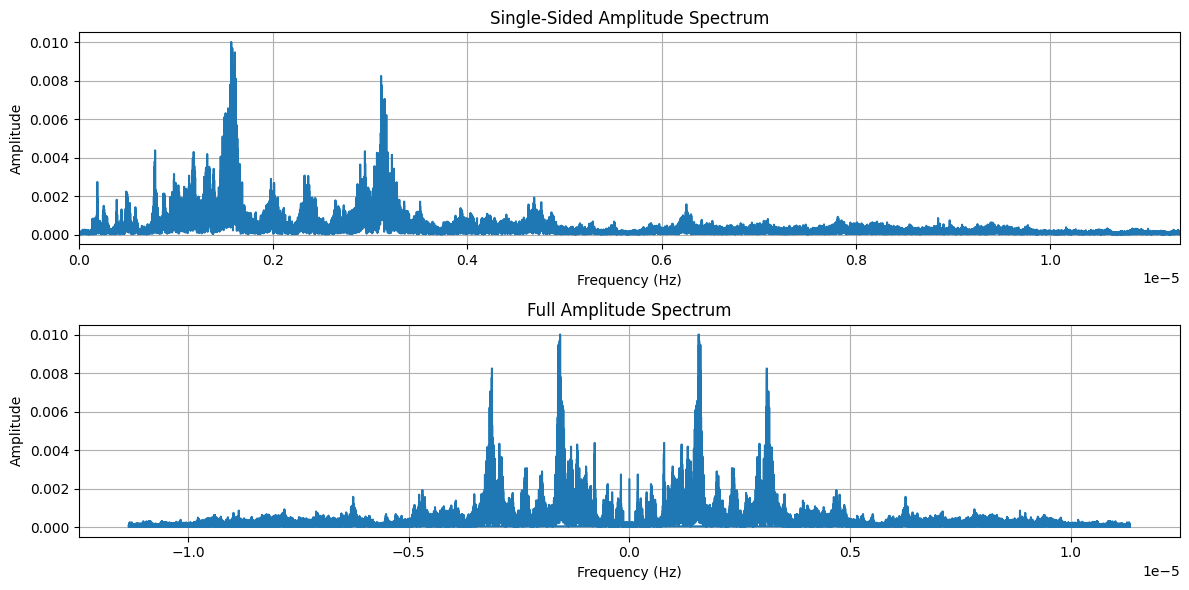

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from google.colab import files
from scipy.fft import fft, fftfreq

sampling_frequency = 1/44100

print ('\n arquivo de handel.wav \n')
files.upload()
audio, file_fs = sf.read('handel.wav')
duracao_audio = len(audio)/file_fs

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(audio, sampling_frequency, single_sided=True)
frequencies_full, amplitudes_full = calculate_spectrum(audio, sampling_frequency, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)

print ('\n gráfico do handel.wav \n')
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, sampling_frequency / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

Pratica 3 Exercício 3

Pratica 3 Exercício 4

Pratica 3 Exercício 5

Pratica 3 Exercício 6

Pratica 3 Exercício 7